# Starbucks User Segmentation

Aditya Raj IIT BHU'26

Table of Contents:

- Modeling & Evaluation
- Discussion & Conclusion

### Importing Libraries

In [112]:
from IPython.display import display
import pandas as pd
import numpy as np
import json
import time

from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('ggplot')
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")  


In [113]:
coe = pd.read_csv('final_coe.csv')
coe.head()

,gender,age,income,days_member,offer_received,offer_viewed,offer_completed,channel_web,channel_email,channel_mobile,...,amt_overall,txn_promo,amt_promo,txn_nonpromo,amt_nonpromo,rfm_promo_score,rfm_nonpromo_score,amt_per_test_hour,amt_per_member_day,amt_per_income
0,0,55,112000.0,2996,2,0,0,2,2,2,...,77.01,1,23.22,2,53.79,4.67,2.67,0.107857,0.025704,0.000688
1,0,75,100000.0,3063,4,4,3,2,4,4,...,159.27,6,135.34,1,23.93,2.67,4.67,0.223067,0.051998,0.001593
2,1,68,70000.0,2711,4,3,2,4,4,4,...,57.73,1,18.42,2,39.31,4.33,3.33,0.080854,0.021295,0.000825
3,1,65,53000.0,2787,6,6,5,6,6,6,...,36.43,3,36.43,0,0.00,1.67,0.00,0.051022,0.013071,0.000687
4,1,58,51000.0,2877,3,2,1,3,3,3,...,15.62,4,15.62,0,0.00,2.33,0.00,0.021877,0.005429,0.000306


In [114]:
coe.shape

(14608, 39)

**Schema:**
* `txn_overall`: Count of transactions made anytime during the test.
* `amt_overall`: Sum of amount spent anytime during the test.
* `txn_promo`: Count of transactions made during offer durations (regardless of view or completion).
* `amt_promo`: Sum of amount spent during offer durations (regardless of view or completion).
* `txn_nonpromo`: Count of transactions in-between (outside) offers durations.
* `amt_nonpromo`: Sum of amount spent in-between (outside) offers durations.
* `gender`: Customer's gender {0: Female, 1:Male}
* `age`: Customer's age.
* `income`: Customer's income.
* `days_member`: Number of days as a member of the program (dynamic; as of today's date).
* `offer_received`: Count of total offers received.
* `offer_viewed`: Count of total offers viewed.
* `offer_completed`: Count of total offers completed.
* `channel_web`: Count of total offer received via web.
* `channel_email`: Count of total offer received via email.
* `channel_mobile`: Count of total offer received via mobile.
* `channel_social`: Count of total offer received via social.
* `difficulty`: Average of minimum required to be spent for all offers received.  
* `duration`: Average of validity period for all offers received.
* `offered_reward`: Average of offered reward for all offers received.
* `redeemed_reward`: Average of redeemed reward for all offers received.
* `response_score`: Average of response score for all offers received.
* `bogo_offer_received`: Count of total 'bogo' offers received.
* `disc_offer_received`: Count of total 'discount' offers received.
* `info_offer_received`: Count of total 'informational' offers received.
* `bogo_offer_viewed`: Count of total 'bogo' offers viewed.
* `disc_offer_viewed`: Count of total 'discount' offers viewed.
* `info_offer_viewed`: Count of total 'informational' offers viewed.
* `bogo_offer_completed`: Count of total 'bogo' offers completed.
* `disc_offer_completed`: Count of total 'discount' offers completed.
* `info_offer_completed`: Count of total 'informational' offers completed.
* `bogo_response_score`: Average of response score for all 'bogo' offers received.
* `disc_response_score`: Average of response score for all 'discount' offers received.
* `info_response_score`: Average of response score for all 'informational' offers received.
* `rfm_promo_score`: RFM score during offer durations (regardless of view or completion).
* `rfm_nonpromo_score`: RFM score in-between (outside) offers durations.
* `amt_per_test_hour`: Average spend during the test period per hour.
* `amt_per_member_day`: Average spend during the test period per day as a member of the program.
* `amt_per_income`: Average spend during the test period per income.

In [115]:
coe.isnull().sum()

gender                  0
age                     0
income                  0
days_member             0
offer_received          0
offer_viewed            0
offer_completed         0
channel_web             0
channel_email           0
channel_mobile          0
channel_social          0
difficulty              0
duration                0
offered_reward          0
redeemed_reward         0
response_score          0
bogo_offer_received     0
disc_offer_received     0
info_offer_received     0
bogo_offer_viewed       0
disc_offer_viewed       0
info_offer_viewed       0
bogo_offer_completed    0
disc_offer_completed    0
info_offer_completed    0
bogo_response_score     0
disc_response_score     0
info_response_score     0
txn_overall             0
amt_overall             0
txn_promo               0
amt_promo               0
txn_nonpromo            0
amt_nonpromo            0
rfm_promo_score         0
rfm_nonpromo_score      0
amt_per_test_hour       0
amt_per_member_day      0
amt_per_inco

## 4. Modeling & Evaluation

[K-Means](https://scikit-learn.org/stable/modules/clustering.html#k-means) is selected for clustering. Prior to clustering, the data will be processed as follows:

1. **Power Transformation** ([PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)) to make the data more Gaussian-like and standardized (mean 0, std 1). This ensures K-Means, which assumes isotropic clusters, does not get biased by variables with unequal variances.

2. **Dimensionality Reduction** using [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to capture the directions of maximum variance. Feature weights indicate correlations: same signs → positive correlation, opposite signs → negative correlation.

Before applying K-Means, two analyses are performed:

- **Optimal number of clusters**: Using elbow and silhouette methods, via `plot_optimization_analysis`, evaluated on a random sample to reduce computation.

- **Silhouette Analysis**: Using `plot_silhouette_analysis` to ensure clusters have minimal misclassified points (score < 0), most points above the average silhouette score, and uniform cluster widths.


### 4.1. Feature Transformation and Dimensionality Reduction

In [116]:
# Applying PowerTransformer and PCA to data

# Instantiate transformers object
est = PowerTransformer()
pca = PCA()

# Store transformation result in dataframe
coe_pca = pd.DataFrame(
    pca.fit_transform(est.fit_transform(coe)),
    columns=coe.columns, index=coe.index)

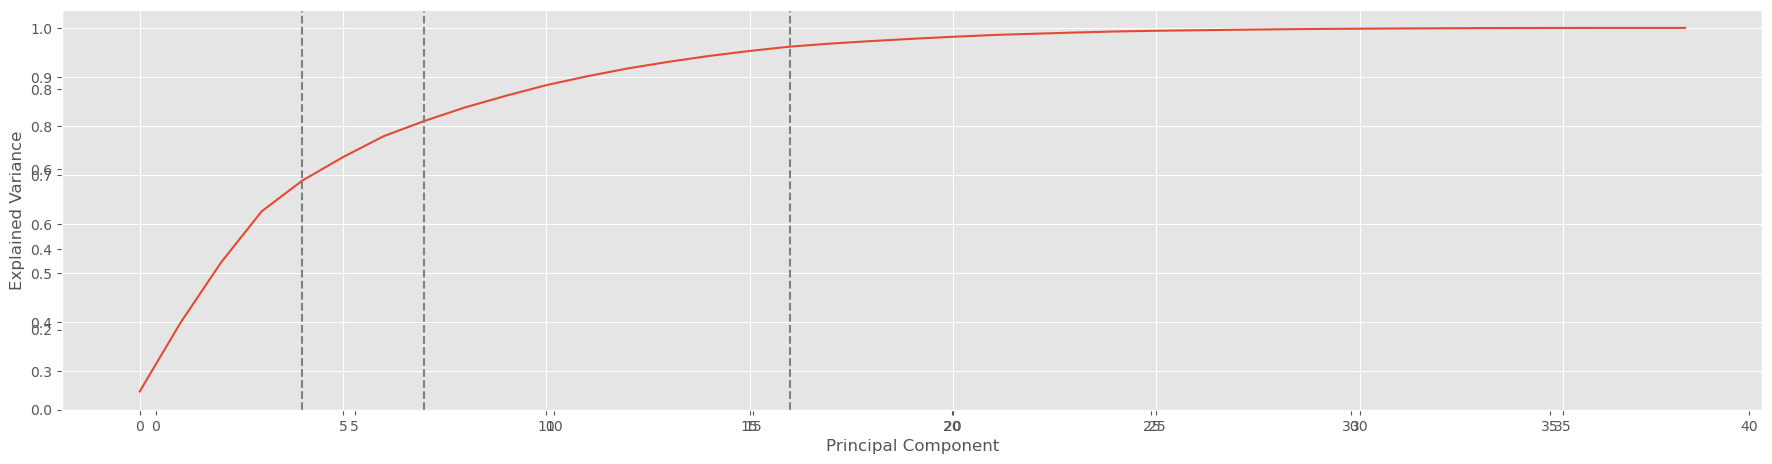

Minimum n_components required for 55% explained variance: 4
Minimum n_components required for 75% explained variance: 7
Minimum n_components required for 95% explained variance: 16


In [117]:
# Investigate the variance accounted for by each principal component

fig = plt.figure(figsize=(17,4))

ax1 = fig.add_axes([0,0,1,1])
ax1.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)

ax2 = fig.add_axes([0,0,1,1])
ax2.plot(np.cumsum(pca.explained_variance_ratio_))

ev_list = [0.55, 0.75, 0.95]
n_components_list = []

for ev in ev_list:
    n_components = min(np.where(np.cumsum(pca.explained_variance_ratio_)>ev)[0]+1)
    ax1.axhline(ev, linestyle='dashed', color='grey')
    ax2.axvline(n_components, linestyle='dashed', color='grey')
    n_components_list.append(n_components)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")

plt.show()

for ev, nc in zip(ev_list, n_components_list):
    print(f'Minimum n_components required for {int(ev*100)}% explained variance: {nc}')

The aim here is use a sufficient percentage to capture the majority of the variability in the data while keeping number of principal components reasonably small. In this particular case, since the original dataframe has only 39 features which in itself is small, 95% explained variance will be used.

In [118]:
def plot_pca_component(df, pca, component, n_features=5):
    """
    Plot the top positive and negative feature weights for a given PCA component.

    Args:
        df (pd.DataFrame): Input dataframe used to fit PCA.
        pca (PCA): Fitted sklearn PCA object.
        component (int): Index of the principal component to visualize.
        n_features (int, optional): Number of top positive and negative features to show. Defaults to 5.

    Returns:
        None
    """
    # PCA component weights and map to column names
    weights = pd.Series(pca.components_[component], index=df.columns)
    
    # top positive and negative weights
    top_pos = weights.nlargest(n_features)
    top_neg = weights.nsmallest(n_features)
    plot_weights = pd.concat([top_pos, top_neg])

    # Plot using seaborn
    plt.figure(figsize=(10, 6))
    sns.barplot(x=plot_weights.values, y=plot_weights.index, palette='coolwarm')
    plt.title(f'PCA Component {component} Feature Weights')
    plt.xlabel('Weight')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


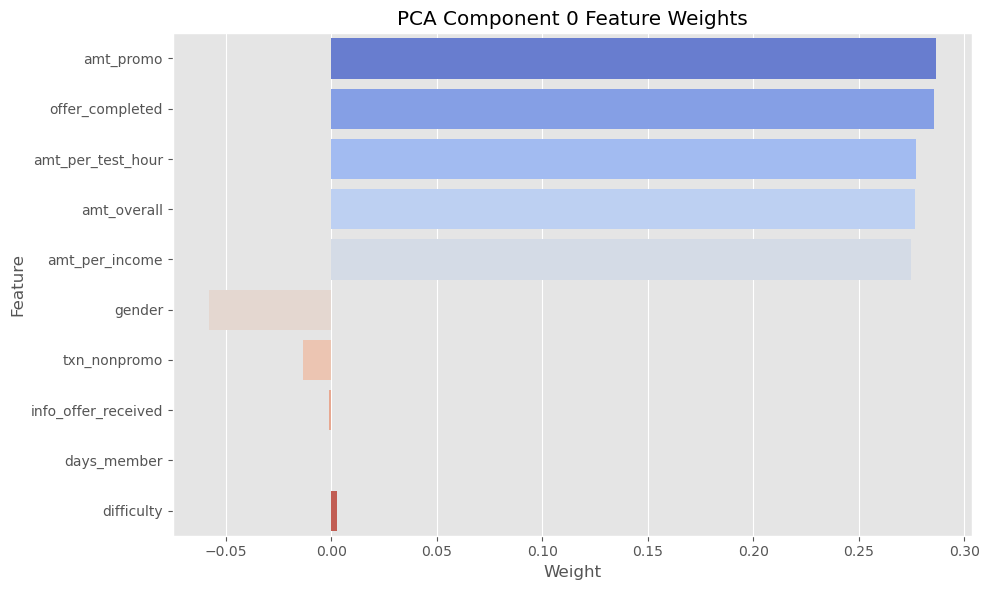

In [119]:
# Investigate the first principal component
plot_pca_component(coe, pca, 0)

PC0 is mostly explained by amount-related features, while demographic-like features (gender, difficulty, days_member) matter far less for this component.

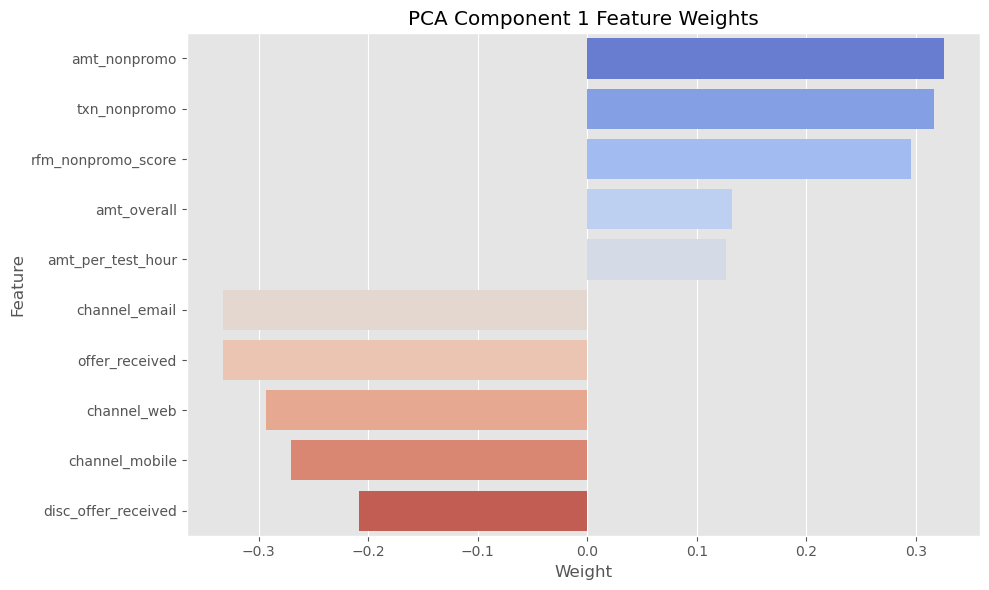

In [99]:
# Investigate the second principal component
plot_pca_component(coe, pca, 1)

PC1 captures the trade-off between non-promotional spending patterns (positive side) and marketing/offer engagement (negative side).

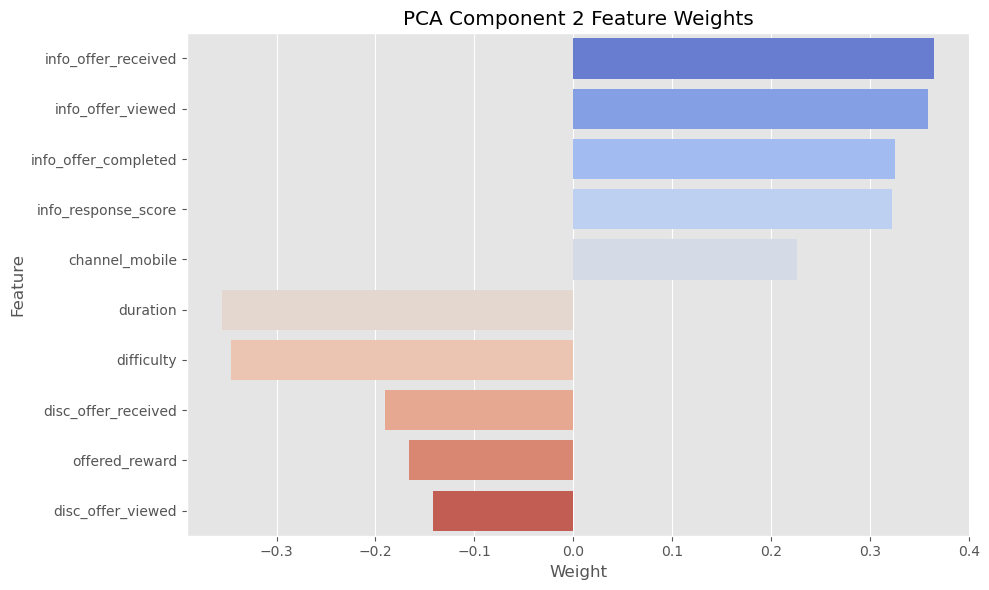

In [120]:
# Investigate the third principal component
plot_pca_component(coe, pca, 2)

PC2 contrasts info/response-based engagement (positive side) vs. discount offer properties and a (negative side).

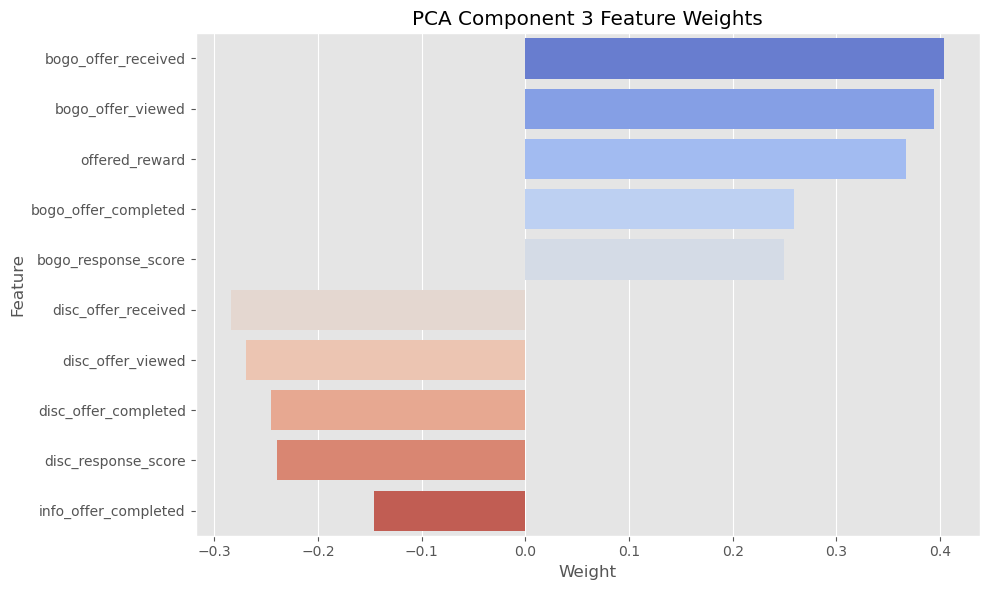

In [121]:
# Investigate the fourth principal component
plot_pca_component(coe, pca, 3)

PC3 is largely associated with bogo and discount offers features.


### 4.2. Modeling & Evaluation

In [122]:
def transform_data(df, ev, tsne=False):
    """
    Apply PowerTransformer(), PCA(), and optionally TSNE() sequentially on dataframe.

    Args:
        df (pd.DataFrame): subject dataframe
        ev (int, float, None, str): explained variance for PCA n_components
        tsne (bool) [default=False]: When True, apply TSNE() on PCA-transformed data

    Returns:
        X (ndarray): transformed dataframe
    """
    # Power transform + PCA
    X = PCA(n_components=ev, random_state=42).fit_transform(
        PowerTransformer().fit_transform(df)
    )

    # Optional TSNE
    if tsne:
        perplexity = int(X.shape[0] ** 0.5)
        X = TSNE(perplexity=perplexity, random_state=42).fit_transform(X)

    return X


In [123]:
def fit_predict_data(X, n_clusters, est='KMeans'):
    """
    Fit clustering model and return labels.

    Args:
        X (array): input data
        n_clusters (int): number of clusters to form
        est (str) [default='KMeans']: estimator; 'KMeans' or 'GaussianMixture'

    Returns:
        model (object): fitted estimator
        labels (array): cluster labels
    """
    est_dict = {
        'KMeans': KMeans(n_clusters=n_clusters, random_state=42),
        'GaussianMixture': GaussianMixture(n_components=n_clusters, random_state=42)
    }

    model = est_dict[est]
    labels = model.fit_predict(X)

    return model, labels


In [124]:
def plot_optimization_analysis(df, ev, est='KMeans', tsne=False, sample_size=0.05):
    """
    Plot change across number of clusters for silhouette score and SSE (KMeans),
    or multiple silhouette trials (GaussianMixture).

    Args:
        df (pd.DataFrame): subject dataframe
        ev (int, float, None, str): PCA explained variance (n_components)
        est (str) [default='KMeans']: 'KMeans' or 'GaussianMixture'
        tsne (bool) [default=False]: When True, apply TSNE after PCA
        sample_size (float) [default=0.05]: fraction of rows for sampling

    Returns:
        None
    """
    # Transform data
    X = transform_data(df, ev, tsne)

    # Cluster range
    n_clusters = list(range(2, 31))

    if est == 'KMeans':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

        # Random sample
        sample = X[np.random.choice(X.shape[0], int(X.shape[0] * sample_size), replace=False)]

        sil_scores, sse_scores = [], []

        for k in n_clusters:
            model, labels = fit_predict_data(sample, k, est)
            sil_scores.append(silhouette_score(sample, labels))
            sse_scores.append(np.abs(model.score(X)))

        # Silhouette plot
        ax1.plot(n_clusters, sil_scores, marker='o')
        ax1.set_title('Silhouette Method')
        ax1.set_xlabel('Clusters')
        ax1.set_ylabel('Silhouette Score')

        # Elbow plot (SSE)
        ax2.plot(n_clusters, sse_scores, marker='o')
        ax2.set_title('Elbow Method')
        ax2.set_xlabel('Clusters')
        ax2.set_ylabel('Sum of Squared Errors')

        transformers = 'PowerTransformer -> PCA' + (' -> TSNE' if tsne else '')

    elif est == 'GaussianMixture':
        fig, axs = plt.subplots(2, 2, figsize=(17, 7))

        for trial, ax in enumerate(axs.ravel(), start=1):
            sample = X[np.random.choice(X.shape[0], int(X.shape[0] * sample_size), replace=False)]

            sil_scores = []
            for k in n_clusters:
                model, labels = fit_predict_data(sample, k, est)
                sil_scores.append(silhouette_score(sample, labels))

            ax.plot(n_clusters, sil_scores, marker='o')
            ax.set_title(f'Trial {trial}')
            ax.set_xlabel('Clusters')
            ax.set_ylabel('Silhouette Coefficient')

        transformers = 'PowerTransformer -> PCA' + (' -> TSNE' if tsne else '')

    # Final formatting
    fig.tight_layout()
    fig.suptitle(f'Optimal Clusters Analysis for {est} Clustering', size=17)
    fig.subplots_adjust(top=0.86)
    fig.text(
        0.5, 0.92,
        f'Transformers: {transformers} | PCA EV: {ev} | Sample Size: {sample_size}',
        ha='center',
        size=14
    )
    plt.show()


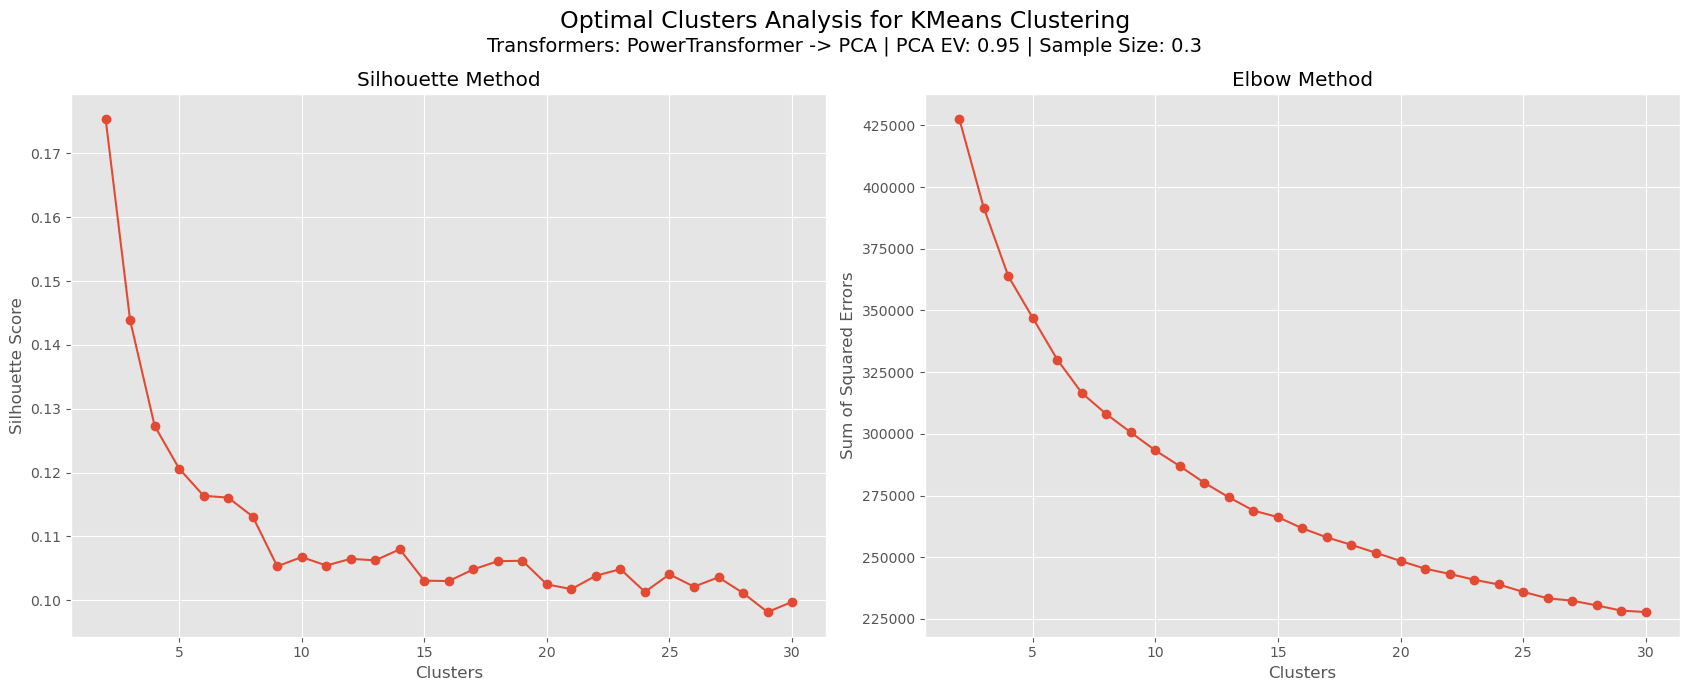

In [105]:
plot_optimization_analysis(
    df = coe,
    ev = 0.95,
    sample_size = 0.3)

The silhouette scores are relatively low, suggesting that the clusters overlap and are not well-separated. The elbow method does not provide a clear inflection point, making it less informative in this case. Based on the silhouette method, 2–3 clusters appear to be optimal. Alternatively, a compromise between both methods would suggest choosing between 4 and 7 clusters.

#### 4.2.2. Performing Silhouette Analysis

In [106]:
def plot_silhouette_analysis(df, ev, n_clusters, est='KMeans', tsne=False):
    """
    Concise silhouette analysis with first two transformed features plotted
    and cluster numbers labeled.

    Args:
        df (pd.DataFrame): Input dataframe
        ev (int, float, None, str): PCA n_components or explained variance
        n_clusters (int): Number of clusters
        est (str): 'KMeans' only (labels and centers plotted)
        tsne (bool): If True, apply TSNE after PCA
    """
    # Transform data
    X = PowerTransformer().fit_transform(df)
    X = PCA(n_components=ev, random_state=42).fit_transform(X)
    if tsne:
        X = TSNE(perplexity=int(X.shape[0]**0.5), random_state=42).fit_transform(X)

    # Fit KMeans
    model = KMeans(n_clusters=n_clusters, random_state=42)
    labels = model.fit_predict(X)

    # Silhouette score
    sil_score = silhouette_score(X, labels)
    print(f"Average silhouette score: {sil_score:.3f}")

    # Plot first two features colored by cluster
    plt.figure(figsize=(10,6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Spectral', s=30, alpha=0.7)
    
    # Show cluster numbers at cluster centers
    if est == 'KMeans':
        centers = model.cluster_centers_
        plt.scatter(centers[:, 0], centers[:, 1], c='white', s=200, edgecolor='k')
        for i, c in enumerate(centers):
            plt.text(c[0], c[1], str(i), color='black', fontsize=12,
                     fontweight='bold', ha='center', va='center')

    plt.title(f'Silhouette Analysis for {est} (score={sil_score:.3f})')
    plt.xlabel('1st feature')
    plt.ylabel('2nd feature')
    plt.show()


Average silhouette score: 0.173


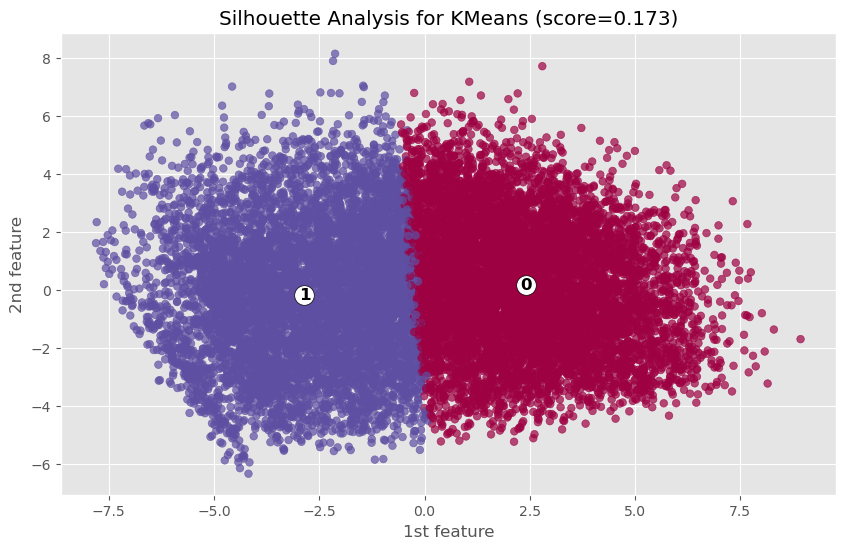

In [125]:
# Investigate silhouette analysis plot with n_clusters=2
plot_silhouette_analysis(
    df = coe,
    ev = 0.95,
    n_clusters = 2)

Average silhouette score: 0.144


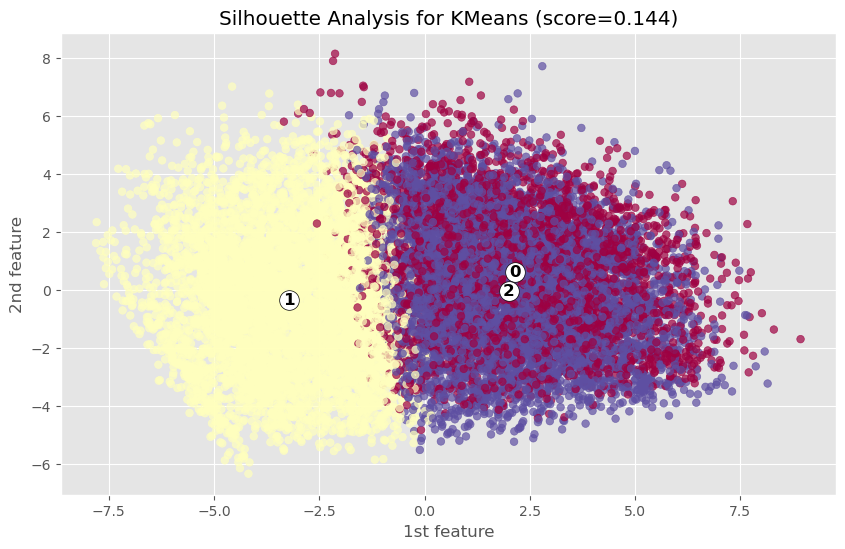

In [126]:
# Investigate silhouette analysis plot with n_clusters=3
plot_silhouette_analysis(
    df = coe,
    ev = 0.95,
    n_clusters = 3)

Average silhouette score: 0.126


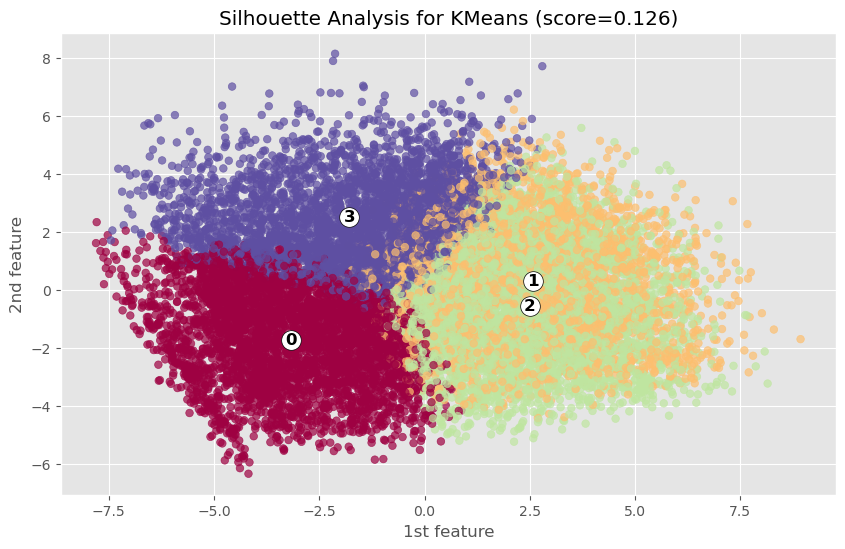

In [109]:
# Investigate silhouette analysis plot with n_clusters=3
plot_silhouette_analysis(
    df = coe,
    ev = 0.95,
    n_clusters = 4)

Average silhouette score: 0.114


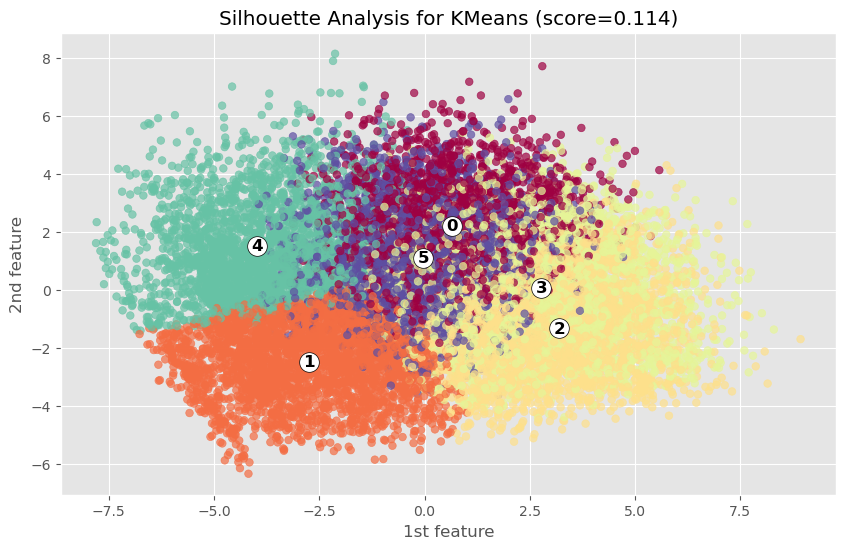

In [127]:
# Investigate silhouette analysis plot with n_clusters=6
plot_silhouette_analysis(
    df = coe,
    ev = 0.95,
    n_clusters = 6)

Based on the graphs above, 6 clusters appear to be the most reasonable choice, with 2 and, to a lesser extent, 3 clusters as alternative options. For the purposes of this analysis, we will proceed with 6 clusters as the optimal configuration.

In [128]:
# Set desired parameters
n_clusters = 6
ev = 0.95
est = 'KMeans'

# Transform, fit, and predict
X = transform_data(coe, ev)
model, labels = fit_predict_data(X, n_clusters, est)

# Store predicted labels in `coe` dataframe
coe['cluster'] = labels

print(f'{est} with {n_clusters} Clusters\n', 'Silhouette Score: ', np.round(silhouette_score(X, labels), 2))

KMeans with 6 Clusters
 Silhouette Score:  0.11


Again, it is worth noting here that the silhouette score (coefficient) is lower than one would have hoped. This indicates overlapping clusters or the data is not clustrable. Nonetheless, outcome clusters will be investigated below.

In [141]:
def plot_cluster_analysis(plot, df, target_columns, title, cluster_column='cluster', print_stats=True):
    """
    Plot using seaborn library target_columns and print descriptive statistics
    grouped by cluster_column to analyse clusters formations
    """
    aux_df = df.copy()

    # Helper to print groupwise stats robustly
    def print_group_stats(group_col, value_col):
        g = aux_df.groupby(group_col)[value_col]
        if pd.api.types.is_numeric_dtype(aux_df[value_col]):
            stats = g.describe()[['mean','min','50%','max']].rename(columns={'50%':'median'})
        else:
            # Categorical: show count and mode-like information
            counts = g.value_counts().unstack(fill_value=0)
            # Print counts table
            print(counts.to_string())
            return
        stats = np.round(stats, 2).reset_index()
        print(stats.to_string(index=False))

    # Scatterplot branch
    if plot == 'scatterplot':
        x, y = target_columns[0], target_columns[1]
        n_clusters = np.unique(df[cluster_column]).tolist()
        fig, ax = plt.subplots(1, len(n_clusters), figsize=(17,5), sharey=True, sharex=True)
        for idx, i in enumerate(n_clusters):
            sns.scatterplot(data=df.loc[df[cluster_column]==i], x=x, y=y, ax=ax[idx], s=15)
            ax[idx].set_title(f'Cluster {i}', size=11)
            ax[idx].set_xlabel('')
            ax[idx].set_ylabel('')
        fig.text(0.5, 0.04, x, ha='center', size=11)
        fig.text(0.08, 0.5, y, va='center', rotation='vertical', size=11)
        fig.suptitle(title, size=14)
        fig.subplots_adjust(top=0.86)
        plt.show()
        return

    # Countplot branch
    if plot == 'countplot':
        plt.figure(figsize=(17,5))
        # ensure hue is categorical string to avoid legend error
        aux_df[target_columns] = aux_df[target_columns].astype('category').astype(str)
        sns.countplot(data=aux_df, x=cluster_column, hue=target_columns)
        plt.title(title)
        plt.ylabel('')
        plt.xlabel('Cluster')
        plt.show()
        if print_stats:
            # show counts per cluster per hue level
            ct = aux_df.groupby([cluster_column, target_columns]).size().unstack(fill_value=0)
            print(ct.to_string())
        return

    # Violinplot branch
    if plot == 'violinplot':
        plt.figure(figsize=(17,5))
        if isinstance(target_columns, list) and len(target_columns) == 2:
            x, y = target_columns[0], target_columns[1]
            aux_df[title] = (aux_df[y] / aux_df[x]).replace([np.nan, np.inf], 0)
            y_to_plot = title
        else:
            y_to_plot = target_columns
        sns.violinplot(data=aux_df, x=cluster_column, y=y_to_plot)
        plt.title(title)
        plt.ylabel('')
        plt.xlabel('Cluster')
        plt.show()
        if print_stats:
            print_group_stats(cluster_column, y_to_plot)
        return


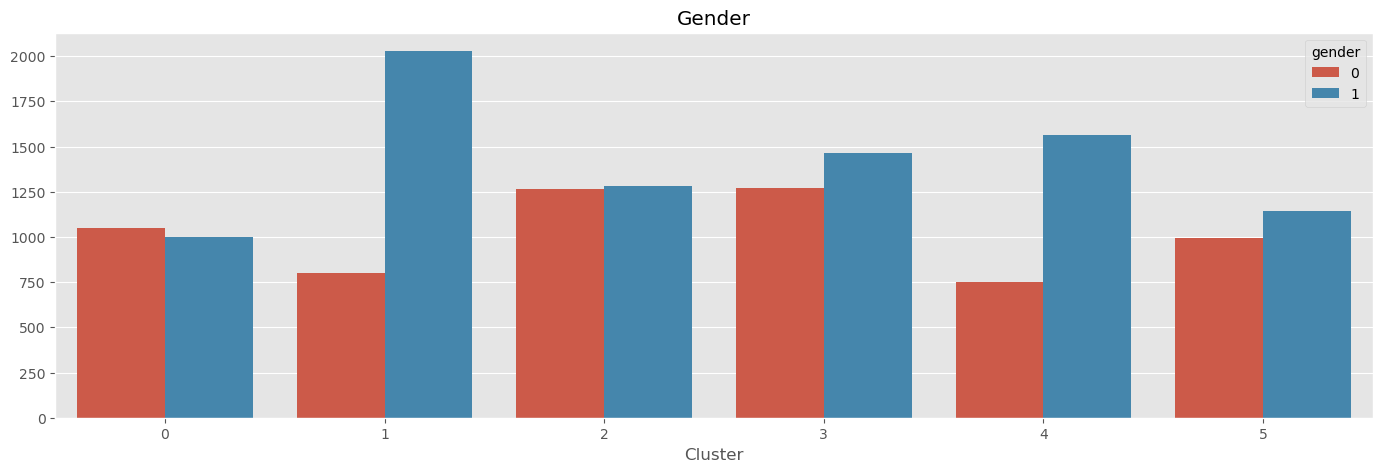

gender      0     1
cluster            
0        1049  1001
1         802  2028
2        1265  1280
3        1268  1465
4         749  1566
5         992  1143


In [130]:
# Investigate `gender` distribution in clusters
plot_cluster_analysis(plot='countplot', df=coe,
                        target_columns='gender',
                        title='Gender')

Column `gender` is a categorical variable so descriptive statistics in this case are arbitrary, but since females are represented by 0 and males by 1, the mean would tell about gender distrbution in a cluster. If mean is about 0.5 then both genders are equally represented in the cluster which is the case for all clusters except clusters `1` and `5` where males are overrepresented. Overall, the model does a decent job in avoiding clusters formation based on gender type.

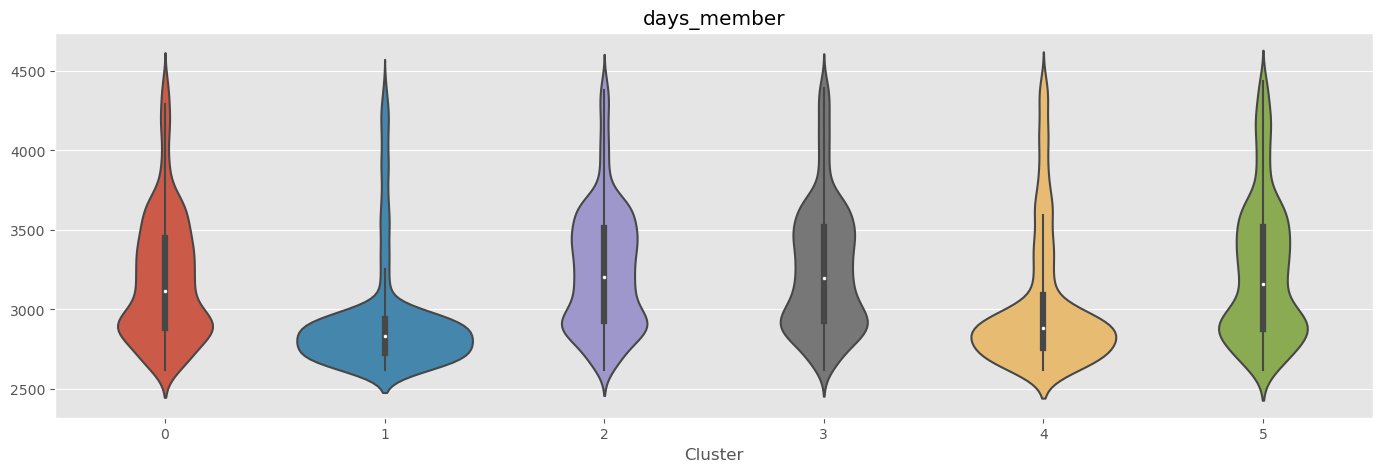

 cluster    mean    min  median    max
       0 3193.84 2620.0  3119.0 4442.0
       1 2923.80 2620.0  2833.0 4430.0
       2 3248.18 2620.0  3206.0 4443.0
       3 3258.60 2620.0  3198.0 4442.0
       4 3023.73 2620.0  2881.0 4442.0
       5 3240.53 2620.0  3160.0 4439.0


In [132]:
# Investigate `age`
plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns='days_member',
                        title='days_member')

Looking at `days_member`, all clusters seem to be formed of similar members in terms of seniority except for clusters `1` and `4` where they are about 200-300 days less in seniority.

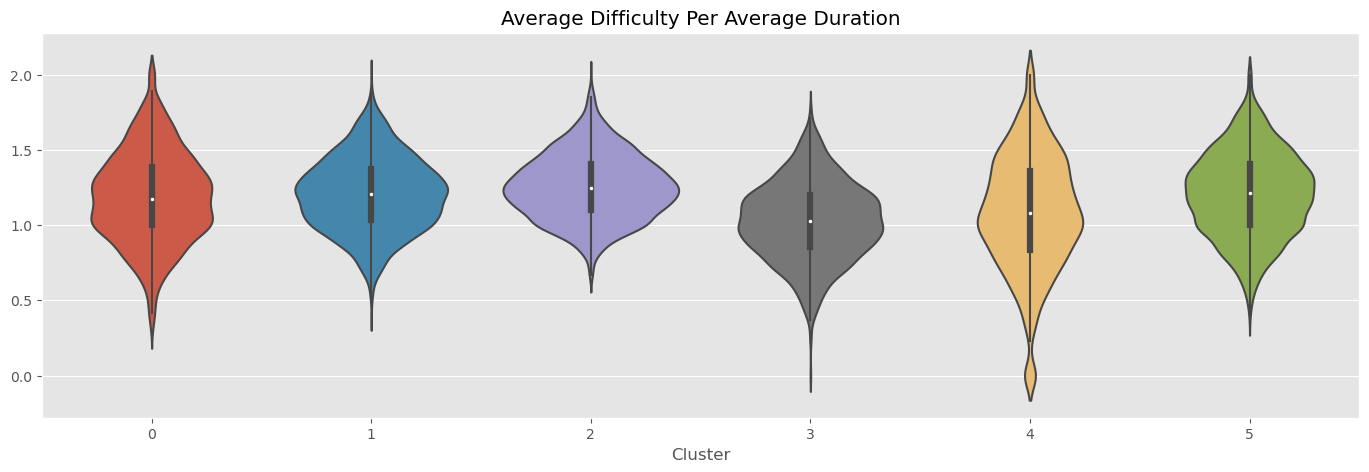

 cluster  mean  min  median  max
       0  1.19 0.31    1.18 2.00
       1  1.21 0.40    1.21 2.00
       2  1.26 0.65    1.25 2.00
       3  1.03 0.00    1.03 1.79
       4  1.09 0.00    1.08 2.00
       5  1.21 0.39    1.21 2.00


In [133]:
# Investigate average `difficulty` per average `duration`
plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns=['duration', 'difficulty'],
                        title='Average Difficulty Per Average Duration')

Another important metric is to see if all clusters were fairly treated in terms of difficulty of offers received. By calculating the average `difficulty` per average `duration` for each customer for all offers received, it can be seen that on average all clusters received a difficulty of about \\$1 per day in duration.

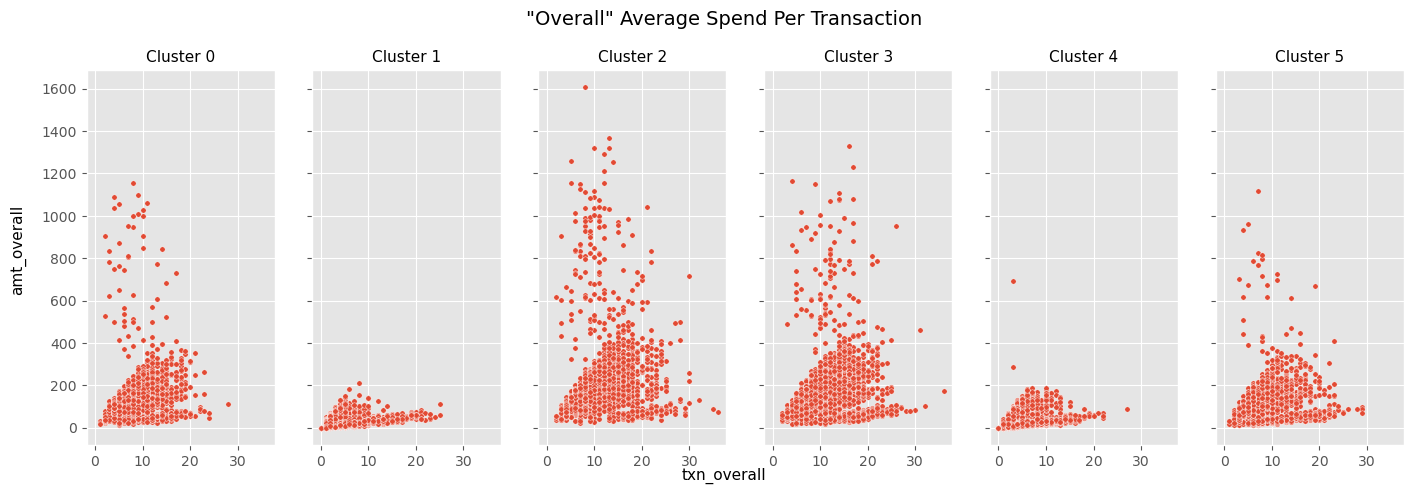

In [142]:
plot_cluster_analysis(plot='scatterplot', df=coe,
                        target_columns=['txn_overall', 'amt_overall'],
                        title='"Overall" Average Spend Per Transaction')

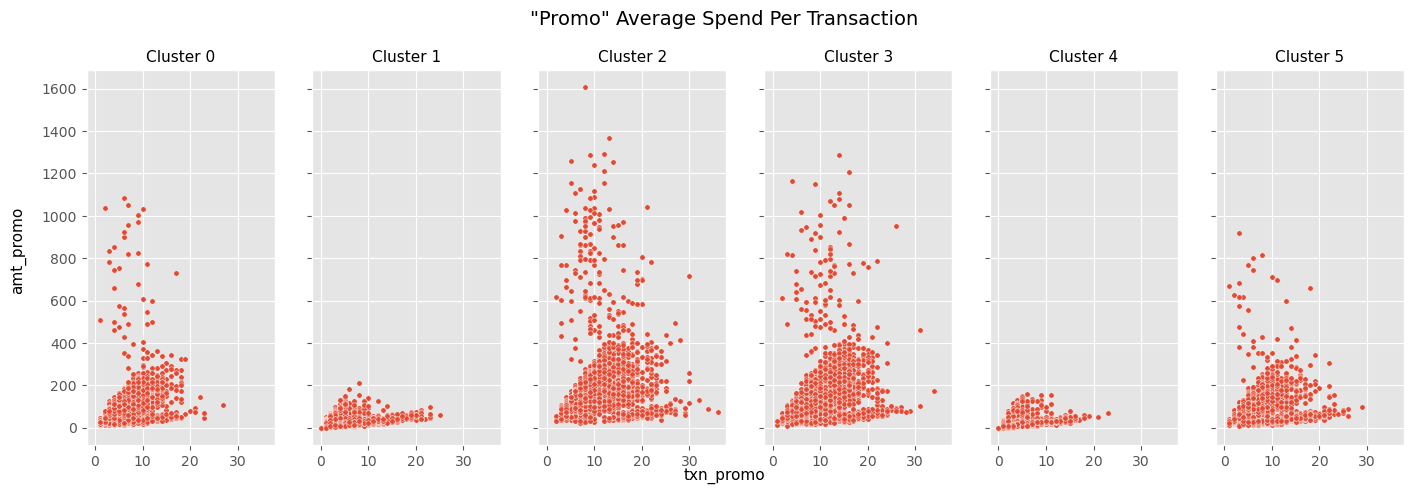

In [143]:
# Investigate "promo" average spend per transaction
plot_cluster_analysis(plot='scatterplot', df=coe,
                        target_columns=['txn_promo', 'amt_promo'],
                        title='"Promo" Average Spend Per Transaction')

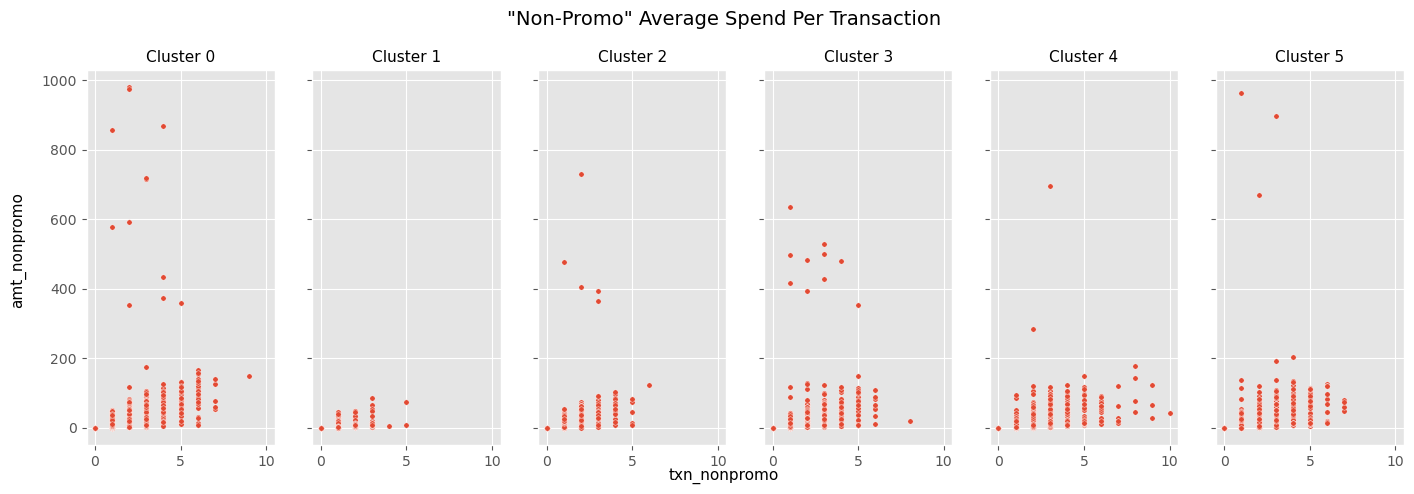

In [144]:
# Investigate "nonpromo" average spend per transaction
plot_cluster_analysis(plot='scatterplot', df=coe,
                        target_columns=['txn_nonpromo', 'amt_nonpromo'],
                        title='"Non-Promo" Average Spend Per Transaction')

- **Cluster 0**: Moderate transactions with modest spend; a stable mid-value cohort across promo and non‑promo.
- **Cluster 1**: Low spend across the board with sparse participation, indicating a low-value or early-stage segment.
- **Cluster 2**: Highest density of mid‑txn, high‑amount purchases, strongly promo‑responsive and valuable.
- **Cluster 3**: Low‑to‑mid spend at moderate txn counts, steady but not promo‑led.
- **Cluster 4**: High spend potential even off‑promo with episodic promo spikes, making it a premium-leaning cohort.
- **Cluster 5**: Consistently low spend and engagement, requiring reactivation rather than more discounts.

In [145]:
def compute_nil_pct(df, target_column, cluster_column='cluster'):
    '''
    Print percentages of nil values in an arry grouped by cluster_column primarily
    designed to assess customers who never made any transactions in a given period
    hence only tested on columns; 'txn_overall', 'txn_promo', and 'txn_nonpromo'

    Args:
    df (pd.DataFrame): subject dataframe
    target_column (str): column to investigate
    cluster_column (str) [default='cluster'] = column holding cluster labels

    Return:
    None
    '''

    # Get set of clusters labels
    n_clusters = np.unique(df[cluster_column]).tolist()

    # Instantiate list to holde percentage values
    idle_pct = []

    # For each cluster
    for i in n_clusters:
        # Get normalized value_counts for target_column
        pct = df.loc[df[cluster_column]==i][target_column].value_counts(normalize=True)
        # Assess zero value exist
        if 0 in pct:
            # Append percentage of zero values to `idle_pct`
            idle_pct.append(pct[0])
        else:
            # Append 0 percent to `idle_pct`
            idle_pct.append(0)

    # Create output_df
    output_df = pd.DataFrame({'cluster': n_clusters, 'pct': idle_pct})
    output_df['pct'] = np.round(output_df.pct * 100, 1)

    # Show output
    print(output_df.to_string(index=False))

In [146]:
# Investigate idle customers (with zero transactions) in `txn_promo`
compute_nil_pct(df=coe, target_column='txn_promo')

 cluster  pct
       0  0.0
       1  9.2
       2  0.0
       3  0.0
       4  9.5
       5  0.0


In [148]:
# Investigate idle customers (with zero transactions) in `txn_nonpromo`
compute_nil_pct(df=coe, target_column='txn_nonpromo')

 cluster  pct
       0 13.9
       1 78.6
       2 68.4
       3 44.6
       4 17.7
       5 26.7


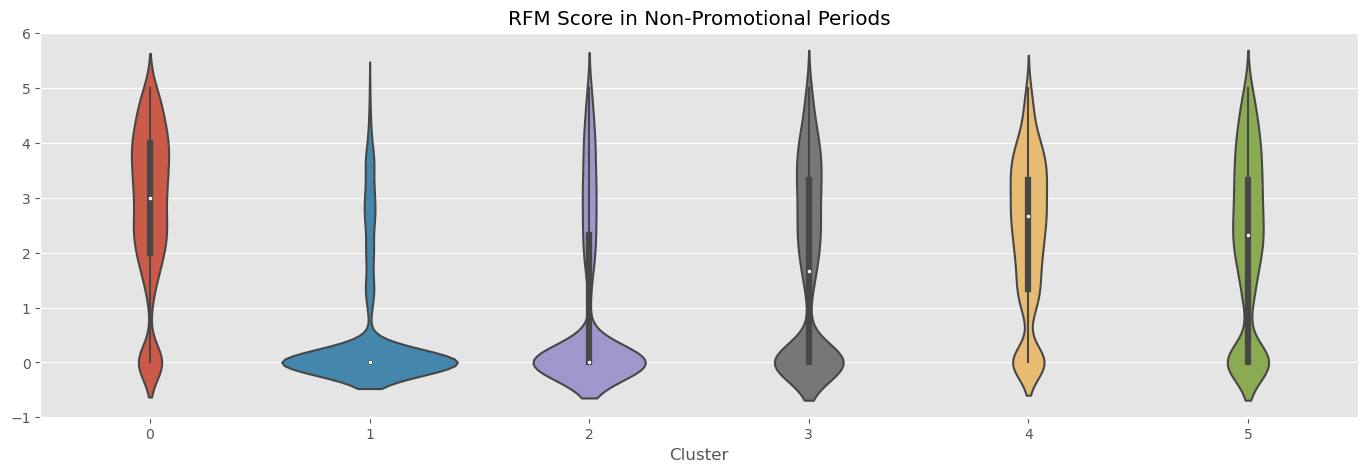

 cluster  mean  min  median  max
       0  2.78  0.0    3.00  5.0
       1  0.56  0.0    0.00  5.0
       2  0.98  0.0    0.00  5.0
       3  1.68  0.0    1.67  5.0
       4  2.30  0.0    2.67  5.0
       5  2.18  0.0    2.33  5.0


In [149]:
# Investigate RFM score in non-promotional periods
plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns='rfm_nonpromo_score',
                        title='RFM Score in Non-Promotional Periods')

In non-promotional periods, cluster 4 are most valuable to business with a mean RFM score of 2.30 and median of 2.67. Followed by cluster 5 with a mean RFM score of 2.18 and median of 2.33.

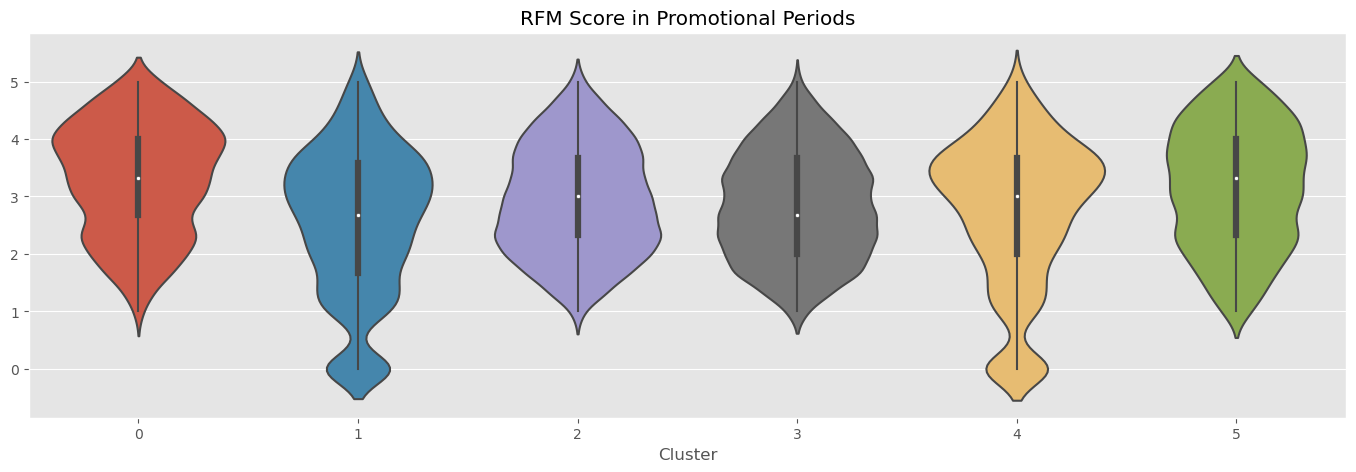

 cluster  mean  min  median  max
       0  3.31  1.0    3.33  5.0
       1  2.56  0.0    2.67  5.0
       2  2.92  1.0    3.00  5.0
       3  2.83  1.0    2.67  5.0
       4  2.74  0.0    3.00  5.0
       5  3.15  1.0    3.33  5.0


In [150]:
# # Investigate RFM score in promotional periods
plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns='rfm_promo_score',
                        title='RFM Score in Promotional Periods')

Promotional periods boost activity for all clusters with the lowest mean RFM score of 2.56 and a median of 2.67.

In [151]:
def compute_percentage_change(df, initial, final, cluster_column='cluster'):
    '''
    Print center measurements for initial and final arrays and thier percentage
    change grouped by cluster_column primarily designed to assess percentage
    chnage increase in average RFM scores from 'nonpromo' to 'promo' periods
    hence only tested on columns; 'rfm_nonpromo_score' and 'rfm_promo_score'

    Args:
    df (pd.DataFrame): subject dataframe
    initial, final (str): column labels with values to investigate
    cluster_column (str) [default='cluster'] = column holding cluster labels

    Return:
    None
    '''

    # Group by cluster_column and get center measurements
    initial_stats = df.groupby(cluster_column)[initial].describe()[
        ['mean', '50%']].rename(columns={'50%': 'median'})

    final_stats = df.groupby(cluster_column)[final].describe()[
        ['mean', '50%']].rename(columns={'50%': 'median'})

    # Create merged output_df
    output_df = pd.merge(initial_stats, final_stats,
                         right_index=True, left_index=True,
                         suffixes=('_initial', '_final'))

    # Round all data of output_df
    output_df = np.round(output_df, 2)

    # Get data arrays to make later steps cleaner
    initial_mean = output_df['mean_initial']
    final_mean = output_df['mean_final']
    initial_median = output_df['median_initial']
    final_median = output_df['median_final']

    # Perform calculations and store results in relevant columns
    output_df['mean_%chnage'] = np.round(
        (final_mean - initial_mean) / initial_mean * 100, 2)

    output_df['median_%chnage'] = np.round(
        (final_median - initial_median) / initial_median * 100, 2)

    # Reorder output_df
    output_df = output_df[
        ['mean_initial', 'mean_final', 'mean_%chnage',
        'median_initial', 'median_final', 'median_%chnage']]

    print(output_df.reset_index().to_string(index=False))


In [152]:
compute_percentage_change(coe, 'rfm_nonpromo_score', 'rfm_promo_score')

 cluster  mean_initial  mean_final  mean_%chnage  median_initial  median_final  median_%chnage
       0          2.78        3.31         19.06            3.00          3.33           11.00
       1          0.56        2.56        357.14            0.00          2.67             inf
       2          0.98        2.92        197.96            0.00          3.00             inf
       3          1.68        2.83         68.45            1.67          2.67           59.88
       4          2.30        2.74         19.13            2.67          3.00           12.36
       5          2.18        3.15         44.50            2.33          3.33           42.92


Considering non‑promo RFM scores as initial and promo RFM scores as final, three takeaways emerge when grounded in the provided numbers: mean RFM increases across all clusters, ranging from about 19% to 357%, with the largest relative gains where the initial baseline was low (e.g., clusters with mean rising from 0.56→2.56 at +357.14% and 0.98→2.92 at +197.96%), medians frequently jump from 0 to positive values in highly responsive segments (rendered as “inf” because the initial median is 0, such as 0.00→2.67 and 0.00→3.00), and clusters that already had higher baselines still improve but at modest rates (e.g., 2.78→3.31 at +19.06% with median 3.00→3.33 at +11.00, and 2.30→2.74 at +19.13% with median 2.67→3.00 at +12.36), indicating that promotions both activate dormant customers and lift already active ones, with targeting priority on segments showing triple‑digit mean lifts and zero‑to‑positive median shifts.

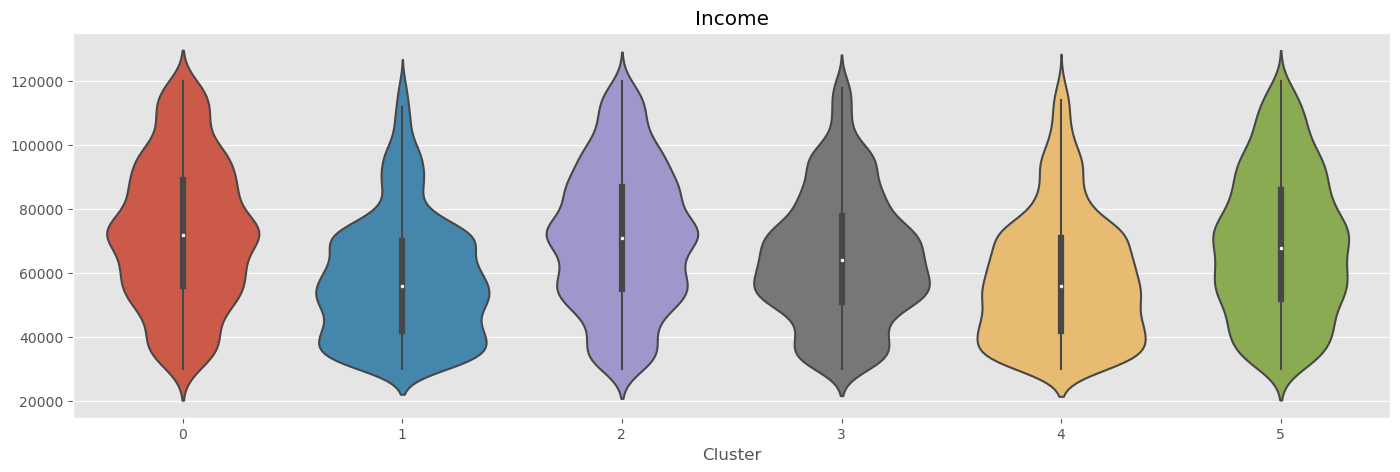

 cluster     mean     min  median      max
       0 72673.66 30000.0 72000.0 120000.0
       1 58182.33 30000.0 56000.0 119000.0
       2 71218.86 30000.0 71000.0 120000.0
       3 65080.13 30000.0 64000.0 120000.0
       4 58653.13 30000.0 56000.0 120000.0
       5 69029.51 30000.0 68000.0 120000.0


In [153]:
# Investigate `income`
plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns='income',
                        title='Income')

Investigating `income` supports the narrative above to some extent. Cluster `0` with the highest mean income of \\$72,673 explaining their high activity during non-promotional periods. It worth noting cluster `2` which is the second highest income group, but these costumes were one of the lowest active during non-promotional periods and only active if promoted to do so. In contrast, while cluster `1` mean income is low, there are moderately active between the two periods as discussed above.

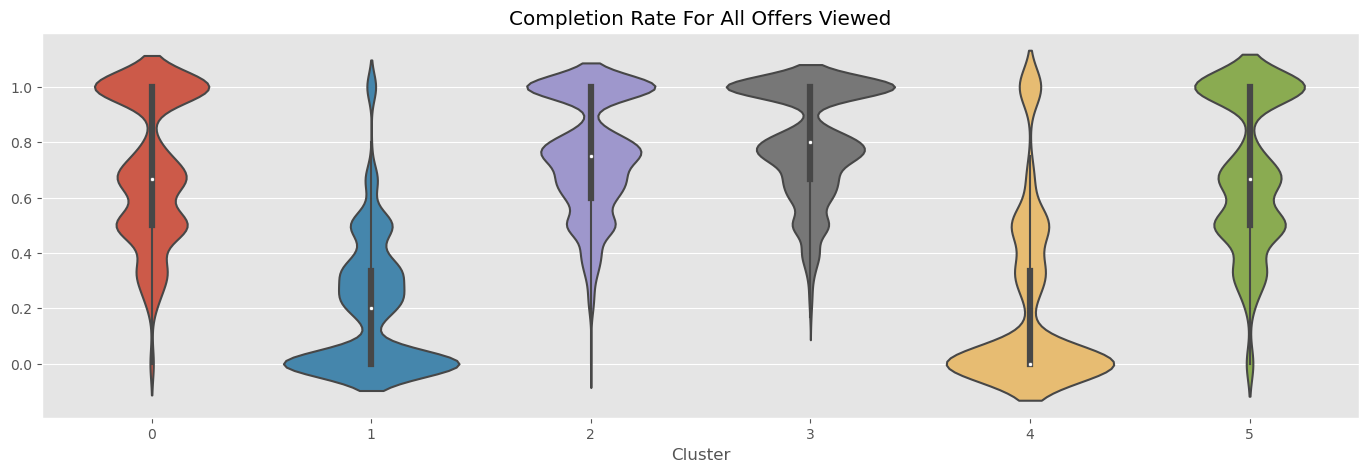

 cluster  mean  min  median  max
       0  0.70 0.00    0.67  1.0
       1  0.20 0.00    0.20  1.0
       2  0.75 0.00    0.75  1.0
       3  0.80 0.17    0.80  1.0
       4  0.21 0.00    0.00  1.0
       5  0.69 0.00    0.67  1.0


In [154]:
# Investigate completion rates as percentage of all offers viewed
plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns=['offer_viewed', 'offer_completed'],
                        title='Completion Rate For All Offers Viewed')

Looking at completion rate for all offers as a percentage of offers viewed (not received). Clusters `0`, `2`, `3`, and `5` completed around 70-80% of all offers they have viewed. Clusters `1` and `4` only completed about 20% of all offers they have viewed.

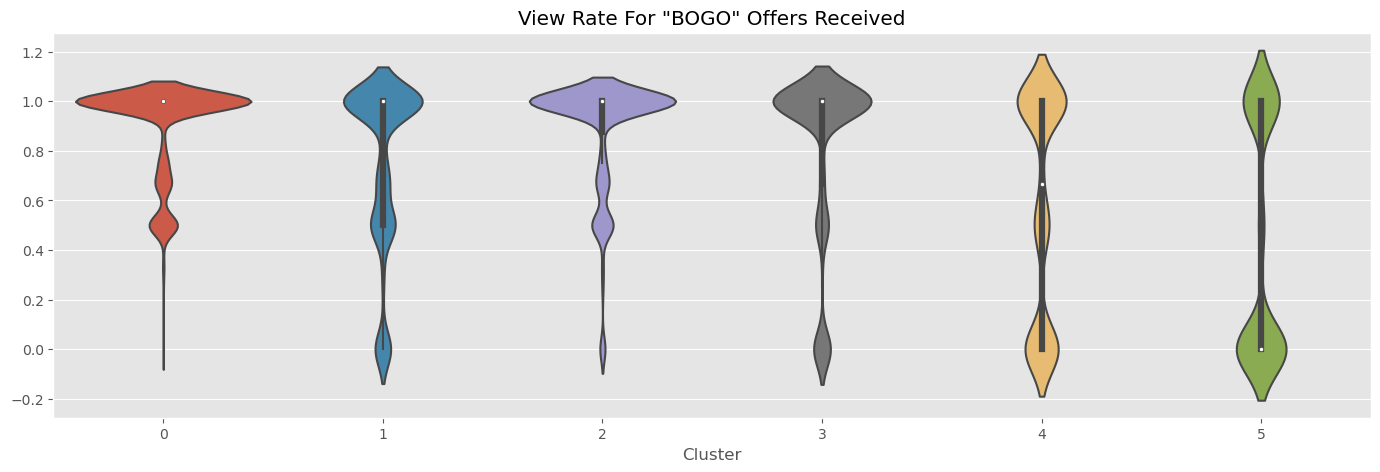

 cluster  mean  min  median  max
       0  0.90  0.0    1.00  1.0
       1  0.75  0.0    1.00  1.0
       2  0.88  0.0    1.00  1.0
       3  0.81  0.0    1.00  1.0
       4  0.58  0.0    0.67  1.0
       5  0.43  0.0    0.00  1.0


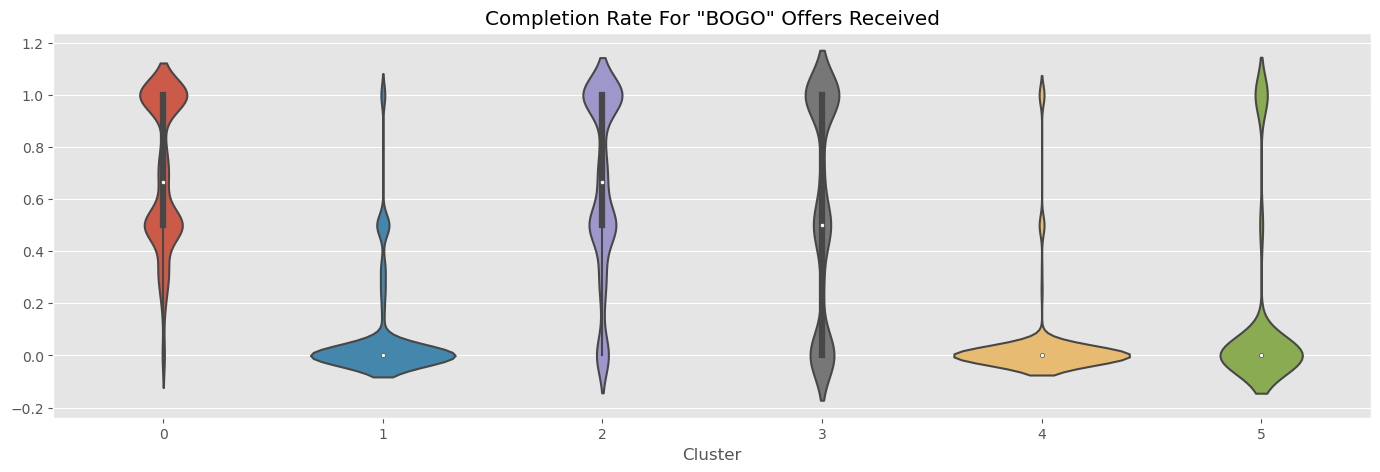

 cluster  mean  min  median  max
       0  0.70  0.0    0.67  1.0
       1  0.08  0.0    0.00  1.0
       2  0.64  0.0    0.67  1.0
       3  0.56  0.0    0.50  1.0
       4  0.04  0.0    0.00  1.0
       5  0.14  0.0    0.00  1.0


In [155]:
# Investigate viewership and completion rates as percentage of "bogo" offers received
for column, title in zip(['bogo_offer_viewed', 'bogo_offer_completed'], ['View', 'Completion']):
    plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns=['bogo_offer_received', column],
                        title=f'{title} Rate For "BOGO" Offers Received')

Looking at view and completion rates for "bogo" offers, all clusters have relatively high view rate with the lowesest being 58% and 43% for cluster `3` and `5`respectively but completion rates varies. Actually, clusters `0`, `2`, and `3` have 50-70% view rates and completion rates indicating these clusters do in fact like "bogo" offers. 

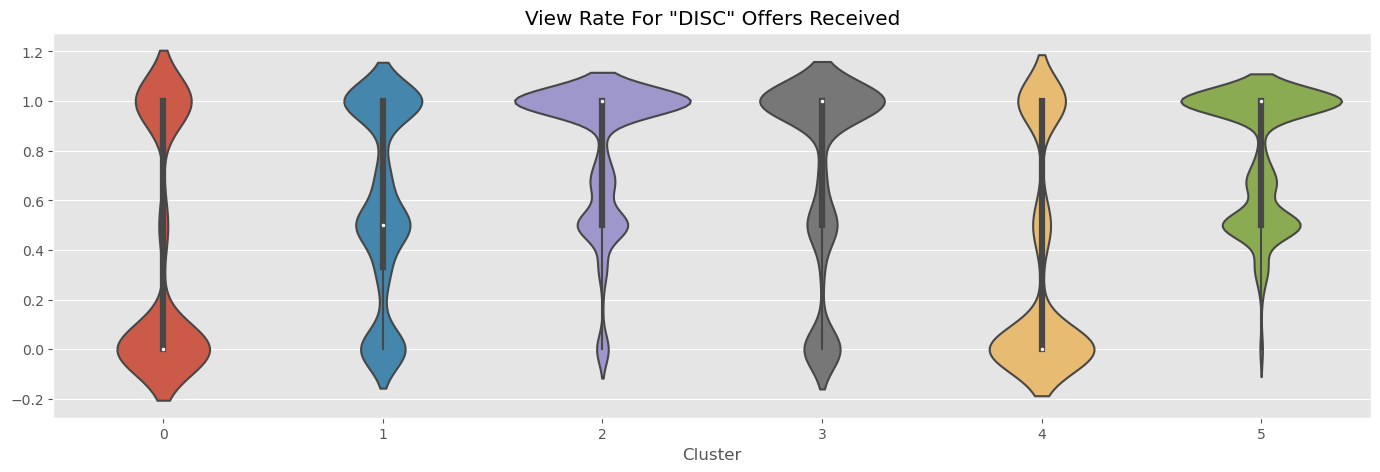

 cluster  mean  min  median  max
       0  0.38  0.0     0.0  1.0
       1  0.58  0.0     0.5  1.0
       2  0.81  0.0     1.0  1.0
       3  0.72  0.0     1.0  1.0
       4  0.33  0.0     0.0  1.0
       5  0.78  0.0     1.0  1.0


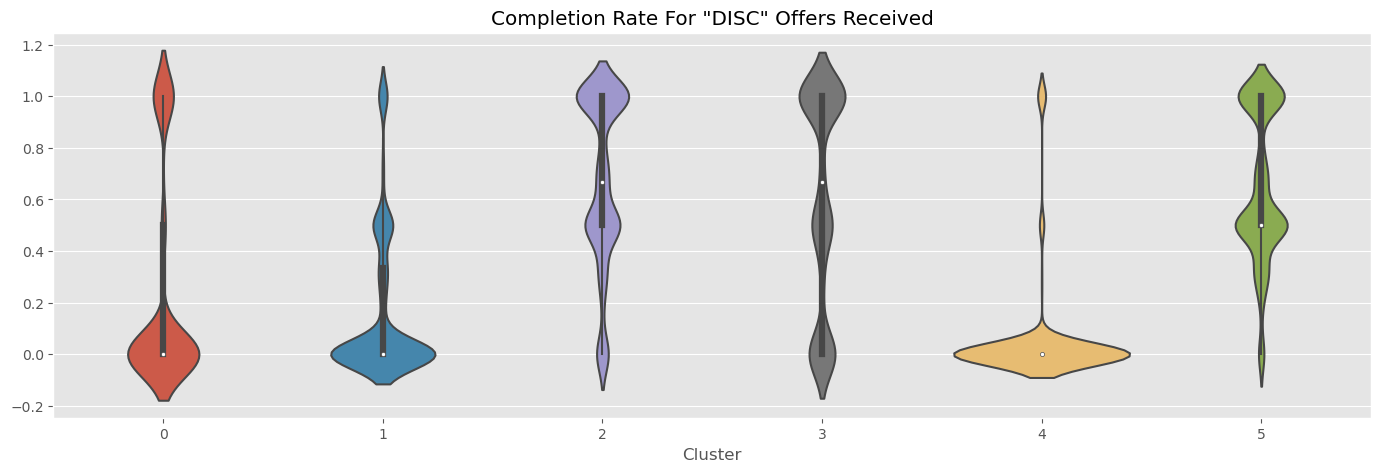

 cluster  mean  min  median  max
       0  0.23  0.0    0.00  1.0
       1  0.16  0.0    0.00  1.0
       2  0.67  0.0    0.67  1.0
       3  0.60  0.0    0.67  1.0
       4  0.05  0.0    0.00  1.0
       5  0.65  0.0    0.50  1.0


In [156]:
for column, title in zip(['disc_offer_viewed', 'disc_offer_completed'], ['View', 'Completion']):
    plot_cluster_analysis(plot='violinplot', df=coe,
                        target_columns=['disc_offer_received', column],
                        title=f'{title} Rate For "DISC" Offers Received')

## 5. Discussion & Conclusion

Now that a better understanding of clusters is formed, it is a good time to reflect on the project as whole. This project started with a lot of data preprocessing on the provided datasets; `portfolio`, `profile`, and `transcript` to produce the final dataset `coe` ready for modeling. PowerTransformer and PCA transformations were then preformed on `coe` which was then fed into K-Means clustering algorithm after deciding on 6 number of clusters.

Technically, the silhouette score (coefficient) was disappointedly low at 0.11 indicating overlapping clusters or data not clustrable. However, after evaluating and investigating the clusters formed, it found to be intuitive. Further discussion on improving the silhouette score later in "improvements" section.

### 5.1. Model Recommendations

In [157]:
# Create dataframe for important metrics to make recommendations

reco = pd.DataFrame()

# Get relevant data; collected individually for convenient
# ordering, renaming, and computing of features on the go

reco['cluster'] = coe.cluster
reco['income'] = coe.income
reco['seniority'] = coe.days_member
reco['response'] = coe.response_score
reco['atv_nonpromo'] = coe.amt_nonpromo / coe.txn_nonpromo
reco['atv_promo'] = coe.amt_promo / coe.txn_promo
reco['rfm_nonpromo'] = coe.rfm_nonpromo_score
reco['rfm_promo'] = coe.rfm_promo_score
reco['view_bogo'] = coe.bogo_offer_viewed / coe.bogo_offer_received
reco['view_disc'] = coe.disc_offer_viewed / coe.disc_offer_received
reco['view_info'] = coe.info_offer_viewed / coe.info_offer_received
reco['complete_bogo'] = coe.bogo_offer_completed / coe.bogo_offer_viewed
reco['complete_disc'] = coe.disc_offer_completed / coe.disc_offer_viewed
reco['complete_info'] = coe.info_offer_completed / coe.info_offer_viewed

# Groupby cluster and aggregate by mean
reco = reco.groupby('cluster').mean()

# Normalize data feature-wise; this allows to plot
# a heatmap representing marks among formed clusters
reco = pd.DataFrame(MinMaxScaler().fit_transform(reco),
                   columns=reco.columns, index=reco.index)

Nomenclature:

* `income`: average income
* `seniority`: average days as a member of the program
* `response`: average response score
* Prefixes
    * `atv_`: average transaction value
    * `rfm_`: recency, frequency, and monetary score  
    * `view_`: view rate of offer received
    * `complete_`: completion rate of offer viewed
* Suffixes
    * `_promo`: in promotional periods
    * `_nonpromo`: in non-promotional periods
    * `_bogo`: "buy one get one" offer type
    * `_disc`: "discount" offer type
    * `_info`: "informational" offer type

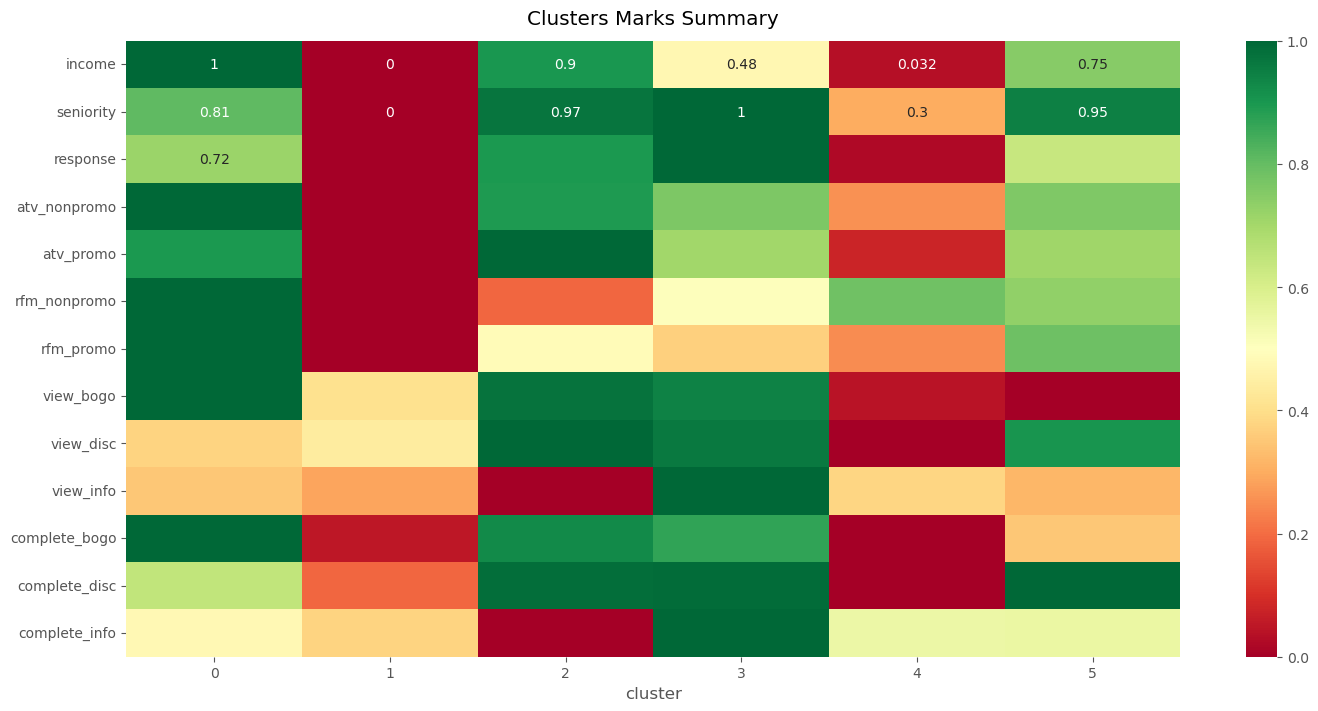

In [160]:
# Plot heatmap
fig = plt.figure(figsize=(17,8))
fig = sns.heatmap(reco.T, annot=True, cmap='RdYlGn')
fig.set_title('Clusters Marks Summary', pad=12)

fig.set_ylim(len(reco.T), 0)
plt.show()

With the help of the plot above and previously collected data, summary of each cluster is as follows:
- **Cluster 0**: Affluent, seasoned, and moderately responsive: income, seniority, and response all score high, signaling stable value and dependable engagement.
Strong non‑promo and promo ATV with top‑tier RFM in both periods; bogo completions are notably high, while info views and completions are lighter.

- **Cluster 1**: Lowest income and seniority with minimal response, indicating newer, value‑constrained members who are hard to activate.
Spend and RFM are uniformly low, and both view and completion rates are depressed across bogo, disc, and info, suggesting broad offer indifference.

- **Cluster 2**: High income, very senior, and solid responder profile that combines strong non‑promo behavior with further lift in promos.
Consistently high ATV and RFM; balanced interest across offer types with above‑average bogo completion and healthy disc performance.

- **Cluster 3**: Mid income and mixed tenure but the strongest promo‑period RFM and high promo ATV, pointing to heavy activation when incentivized.
View and completion marks favor disc and info over bogo, implying informational or price‑led offers outperform one‑to‑one free item deals here.

- **Cluster 4**: Lowest income and response among established members; weak ATV and RFM across periods signal limited revenue impact without targeted intervention.
Offer engagement is broadly low, with especially weak bogo completions, suggesting promotions rarely convert.

- **Cluster 5**: Upper‑middle income and seniority with fair response; promo ATV and RFM are strong and stand out versus non‑promo, indicating incentive sensitivity.
The clearest preference is discount offers, where completion is top‑ranked; bogo and info trail, so price‑based levers are most effective.



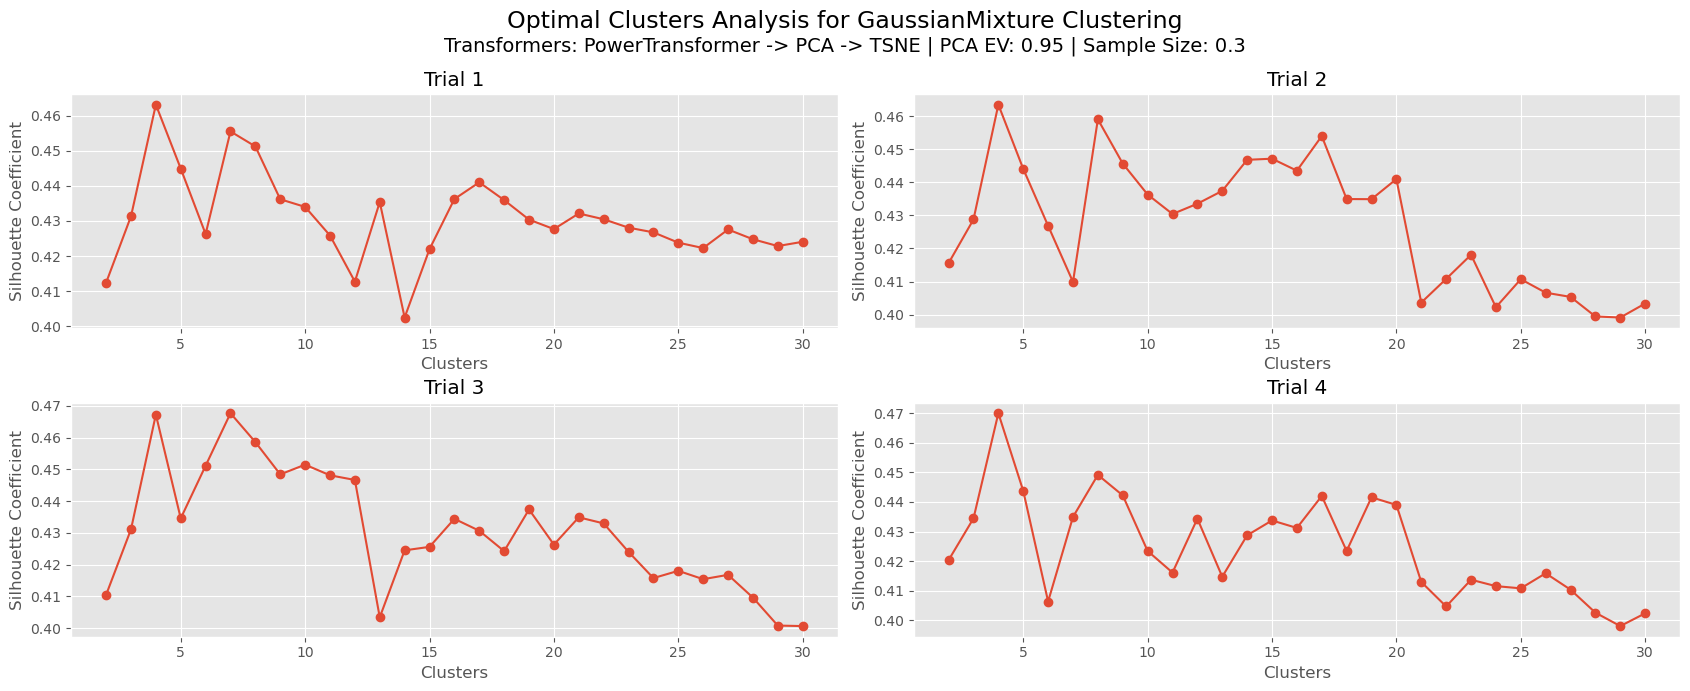

In [162]:
# Investigate change in silhouette across number of clusters
plot_optimization_analysis(
    df = coe,
    est = 'GaussianMixture',
    ev = 0.95,
    tsne = True,
    sample_size = 0.3)

The silhouette score is inconsistent between runs as multiple plots must be observed before making any assessment with t-SNE. After doing that, number of 6 and 7 are proposed as possible optimal numbers of clusters.

Average silhouette score: 0.462


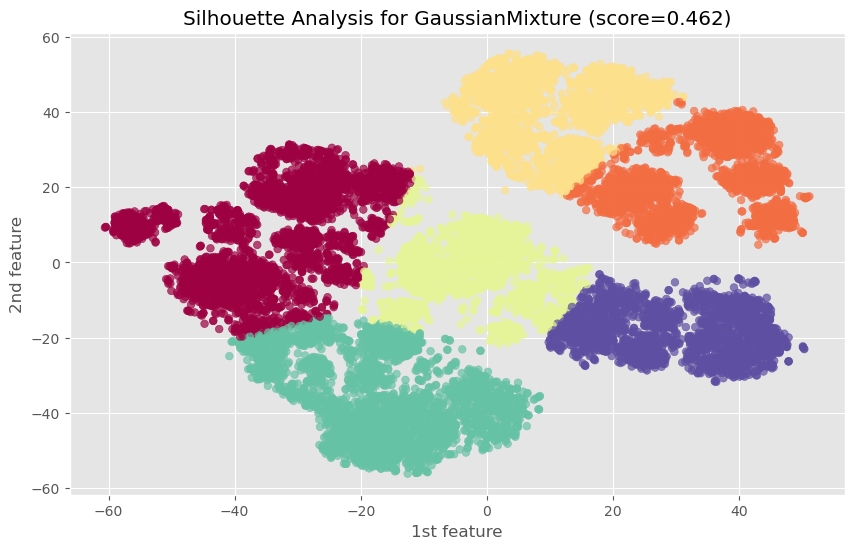

In [164]:
# Investigate silhouette analysis plot with n_clusters=6
plot_silhouette_analysis(
    df = coe,
    est = 'GaussianMixture',
    ev = 0.95,
    tsne = True,
    n_clusters = 6)

Average silhouette score: 0.469


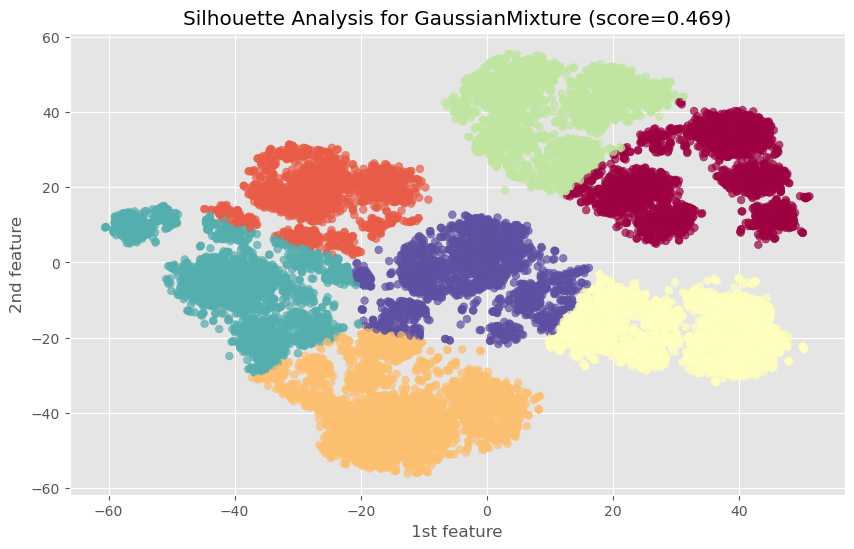

In [165]:
# Investigate silhouette analysis plot with n_clusters=7
plot_silhouette_analysis(
    df = coe,
    est = 'GaussianMixture',
    ev = 0.95,
    tsne = True,
    n_clusters = 7)

It can be seen here that clusters are more distinct. Again, when the formed clusters are investigated they do seem intuitive and more or less inline with results obtained by KMeans model but being unsure of the soundness of this process, it will be left at this.

 I am happy with the number of clusters as 6 clusters are practical from a business perspective. The results of clusters formed after investigation seem intuitive. However, large room for improvement exists.